In [1]:
import sqlite3
import os
import sentencepiece as spm
import torch
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from preprocessing import pad_sequences
print("Imports successful!")

c:\Users\Andrew\Desktop\Romeo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Constants and padding function defined successfully!
Imports successful!


In [2]:
# Constants
MAX_FUNCTION_LINES = 50
MIN_FUNCTION_LINES = 10
MAX_SEQ_LENGTH = 98

Below cell to sanity check the labeleled lines that are being pulled from the dataset

In [ ]:
# Function to display vulnerable lines in code for manual verification
def display_vulnerable_lines(db_path, num_samples=5):
    print(f"Displaying vulnerable lines from {db_path} for manual verification...")
    
    try:
        # Load some vulnerable functions
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        cursor.execute(
            "SELECT cve, file, start, end, vuln, code FROM funcs WHERE vuln IS NOT NULL AND vuln != '' "
            f"AND (end - start ) BETWEEN {MIN_FUNCTION_LINES} AND {MAX_FUNCTION_LINES} "
            "LIMIT ?", (num_samples,)
        )
        vuln_samples = cursor.fetchall()
        
        if not vuln_samples:
            print("No vulnerable samples found!")
            return
        
        # Display each vulnerable sample and highlight the vulnerable lines
        for i, (cve, file, start, end, vuln, code) in enumerate(vuln_samples):
            print(f"\n{'='*80}")
            print(f"Sample {i+1}")
            print(f"{'='*80}")
            print(f"File: {file}")
            print(f"Line range: {start}-{end}")
            print(f"Vulnerability info: {vuln}")
            
            # Parse vulnerability lines
            try:
                vuln_lines = [int(v.strip()) for v in vuln.split(',')]
                
                code_lines = code.split('\n')
                for j, line in enumerate(code_lines):
                    # Calculate absolute line number and check if it's vulnerable
                    print(f"    {j+1:2d}: {line}")
                
                # Show relative line numbers (0-based) for use in model
                print("\nVulnerable line indices for model:")
                rel_lines = [line - start for line in vuln_lines if 0 <= (line - start) < MAX_FUNCTION_LINES]
                print(rel_lines)
                
            except Exception as e:
                print(f"Error parsing vulnerability info: {str(e)}")
        
        conn.close()
        
    except Exception as e:
        print(f"Error displaying vulnerable lines: {str(e)}")

# Run the function to display vulnerable lines from both databases
print("C Vulnerabilities:")
display_vulnerable_lines("c_10+.db", num_samples=10)

print("\nJava Vulnerabilities:")
display_vulnerable_lines("java_10+.db", num_samples=10)

In [47]:
# Database functions
def load_data_from_db(db_path, limit_per_class=None, balance_classes=False):
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # Get functions with vulnerabilities
        cursor.execute(
            "SELECT cve, file, start, end, vuln, code FROM funcs WHERE vuln IS NOT NULL AND vuln != '' "
            f"AND (end - start + 1) BETWEEN {MIN_FUNCTION_LINES} AND {MAX_FUNCTION_LINES}"
        )
        vulnerable_funcs = cursor.fetchall()
        
        # Get functions without vulnerabilities
        cursor.execute(
            "SELECT cve, file, start, end, vuln, code FROM funcs WHERE (vuln IS NULL OR vuln = '') "
            f"AND (end - start + 1) BETWEEN {MIN_FUNCTION_LINES} AND {MAX_FUNCTION_LINES}"
        )
        non_vulnerable_funcs = cursor.fetchall()
        
        # Apply balancing if needed
        if balance_classes and limit_per_class:
            # Limit both classes to the same size
            vuln_limit = min(len(vulnerable_funcs), limit_per_class)
            non_vuln_limit = min(len(non_vulnerable_funcs), limit_per_class)
            
            # If one class is smaller, limit both to the smaller size for balance
            if balance_classes:
                min_size = min(vuln_limit, non_vuln_limit)
                vulnerable_funcs = vulnerable_funcs[:min_size]
                non_vulnerable_funcs = non_vulnerable_funcs[:min_size]
            else:
                vulnerable_funcs = vulnerable_funcs[:vuln_limit]
                non_vulnerable_funcs = non_vulnerable_funcs[:non_vuln_limit]
        
        conn.close()
        # Combine the data
        all_funcs = vulnerable_funcs + non_vulnerable_funcs
        
        return all_funcs, len(vulnerable_funcs), len(non_vulnerable_funcs)
    except Exception as e:
        print(f"Error in load_data_from_db: {str(e)}")
        return [], 0, 0

# Process vulnerability information to create labels
def create_labels(functions):
    data = []
    labels = []
    vuln_count = 0
    
    try:
        for cve, file, start, end, vuln, code in functions:
            data.append(code)
            # Create one-hot encoded vector for vulnerability location
            # If vuln is None or empty, all zeros (no vulnerability)
            label = torch.zeros(MAX_FUNCTION_LINES)
            
            if vuln:
                try:
                    # Parse the vulnerability line(s)
                    vuln_lines = [int(v.strip()) for v in vuln.split(',')]
                    for line_num in vuln_lines:
                        # Just use the integer from vuln directly
                        if 0 <= line_num < MAX_FUNCTION_LINES:
                            label[line_num] = 1
                    
                    # Count this as a vulnerable function if at least one label was set
                    if torch.sum(label) > 0:
                        vuln_count += 1
                except Exception as e:
                    # In case of parsing errors, treat as non-vulnerable
                    pass
            
            labels.append(label)
    except Exception as e:
        print(f"Error in create_labels: {str(e)}")
    
    return data, labels, vuln_count

In [48]:
### Load the tokenizer model from hugging face transformers library 
tokenizer = AutoTokenizer.from_pretrained("aiXcoder/aixcoder-7b-base")

In [49]:
def tokenize_and_pad(data, max_samples=None):
    # Limit samples if needed
    if max_samples and len(data) > max_samples:
        data = data[:max_samples]
        print(f"Limited to {max_samples} samples")
    
    sequences = []
    
    # Use regular tqdm instead of notebook version
    for idx, text in enumerate(data):
        if idx % 5 == 0:
            print(f"Processing sample {idx+1}/{len(data)}...")
        
        # Extract and limit lines
        lines = text.split('\n')[:MAX_FUNCTION_LINES]
        
        # Tokenize each line
        tokenized_lines = [tokenizer.encode(line) for line in lines]
        
        # Pad each line to MAX_SEQ_LENGTH
        padded_lines = pad_sequences(tokenized_lines, maxlen=MAX_SEQ_LENGTH, padding='post')
        
        # Pad to MAX_FUNCTION_LINES if needed
        if len(padded_lines) < MAX_FUNCTION_LINES:
            padding = np.zeros((MAX_FUNCTION_LINES - len(padded_lines), MAX_SEQ_LENGTH))
            padded_lines = np.vstack((padded_lines, padding))
        elif len(padded_lines) > MAX_FUNCTION_LINES:
            padded_lines = padded_lines[:MAX_FUNCTION_LINES]
        
        sequences.append(padded_lines)
    
    # Convert to tensor
    return torch.tensor(np.array(sequences))

For now run0 == manual seed 42
run 1 == manual seed 43


In [ ]:
# Step 1: Load data from databases with class balancing
print("Loading data from databases...")
c_funcs, c_vuln_count, c_non_vuln_count = load_data_from_db("c_10+.db", limit_per_class=5000, balance_classes=True)
java_funcs, java_vuln_count, java_non_vuln_count = load_data_from_db("java_10+.db", limit_per_class=5000, balance_classes=True)

print(f"C Code: {c_vuln_count} vulnerable, {c_non_vuln_count} non-vulnerable, ratio: {c_vuln_count/(c_non_vuln_count or 1):.2f}")
print(f"Java Code: {java_vuln_count} vulnerable, {java_non_vuln_count} non-vulnerable, ratio: {java_vuln_count/(java_non_vuln_count or 1):.2f}")

# Combine data and create labels
all_funcs = c_funcs + java_funcs
data, labels, vuln_count = create_labels(all_funcs)

# Quick check of positive and negative samples in the dataset
pos_samples = sum(1 for l in labels if torch.sum(l) > 0)
neg_samples = len(labels) - pos_samples
print(f"\nDataset class distribution:")
print(f"Positive samples (with vulnerability): {pos_samples} ({pos_samples/len(labels)*100:.2f}%)")
print(f"Negative samples (without vulnerability): {neg_samples} ({neg_samples/len(labels)*100:.2f}%)")
print(f"Positive:Negative ratio = 1:{neg_samples/pos_samples:.2f}" if pos_samples > 0 else "No positive samples found")

# Step 2: Split the data
train_data, temp_data, train_labels, temp_labels = train_test_split(
    data, labels, test_size=0.3, random_state=43, stratify=[1 if torch.sum(l) > 0 else 0 for l in labels]
)
val_data, test_data, val_labels, test_labels = train_test_split(
    temp_data, temp_labels, test_size=0.33, random_state=43
)
print(f"Train: {len(train_data)}, Validation: {len(val_data)}, Test: {len(test_data)} samples")

# Check class distribution in splits
train_pos = sum(1 for l in train_labels if torch.sum(l) > 0)
val_pos = sum(1 for l in val_labels if torch.sum(l) > 0)
test_pos = sum(1 for l in test_labels if torch.sum(l) > 0)

print(f"\nClass distribution after splitting:")
print(f"Train: {train_pos}/{len(train_labels)} positive ({train_pos/len(train_labels)*100:.2f}%)")
print(f"Validation: {val_pos}/{len(val_labels)} positive ({val_pos/len(val_labels)*100:.2f}%)")
print(f"Test: {test_pos}/{len(test_labels)} positive ({test_pos/len(test_labels)*100:.2f}%)")

Loading data from databases...
C Code: 5000 vulnerable, 5000 non-vulnerable, ratio: 1.00
Java Code: 831 vulnerable, 831 non-vulnerable, ratio: 1.00
C Code: 5000 vulnerable, 5000 non-vulnerable, ratio: 1.00
Java Code: 831 vulnerable, 831 non-vulnerable, ratio: 1.00

Dataset class distribution:
Positive samples (with vulnerability): 5831 (50.00%)
Negative samples (without vulnerability): 5831 (50.00%)
Positive:Negative ratio = 1:1.00
Train: 8163, Validation: 2344, Test: 1155 samples

Class distribution after splitting:
Train: 4082/8163 positive (50.01%)
Validation: 1155/2344 positive (49.27%)
Test: 594/1155 positive (51.43%)

Dataset class distribution:
Positive samples (with vulnerability): 5831 (50.00%)
Negative samples (without vulnerability): 5831 (50.00%)
Positive:Negative ratio = 1:1.00
Train: 8163, Validation: 2344, Test: 1155 samples

Class distribution after splitting:
Train: 4082/8163 positive (50.01%)
Validation: 1155/2344 positive (49.27%)
Test: 594/1155 positive (51.43%)


Tokenizing data...
Processing sample 1/8163...
Processing sample 6/8163...
Processing sample 11/8163...
Processing sample 16/8163...
Processing sample 21/8163...
Processing sample 26/8163...
Processing sample 31/8163...
Processing sample 36/8163...
Processing sample 41/8163...
Processing sample 46/8163...
Processing sample 51/8163...
Processing sample 56/8163...
Processing sample 61/8163...
Processing sample 66/8163...
Processing sample 71/8163...
Processing sample 76/8163...
Processing sample 81/8163...
Processing sample 86/8163...
Processing sample 91/8163...
Processing sample 96/8163...
Processing sample 101/8163...
Processing sample 106/8163...
Processing sample 111/8163...
Processing sample 116/8163...
Processing sample 121/8163...
Processing sample 126/8163...
Processing sample 131/8163...
Processing sample 136/8163...
Processing sample 141/8163...
Processing sample 146/8163...
Processing sample 151/8163...
Processing sample 156/8163...
Processing sample 161/8163...
Processing sa

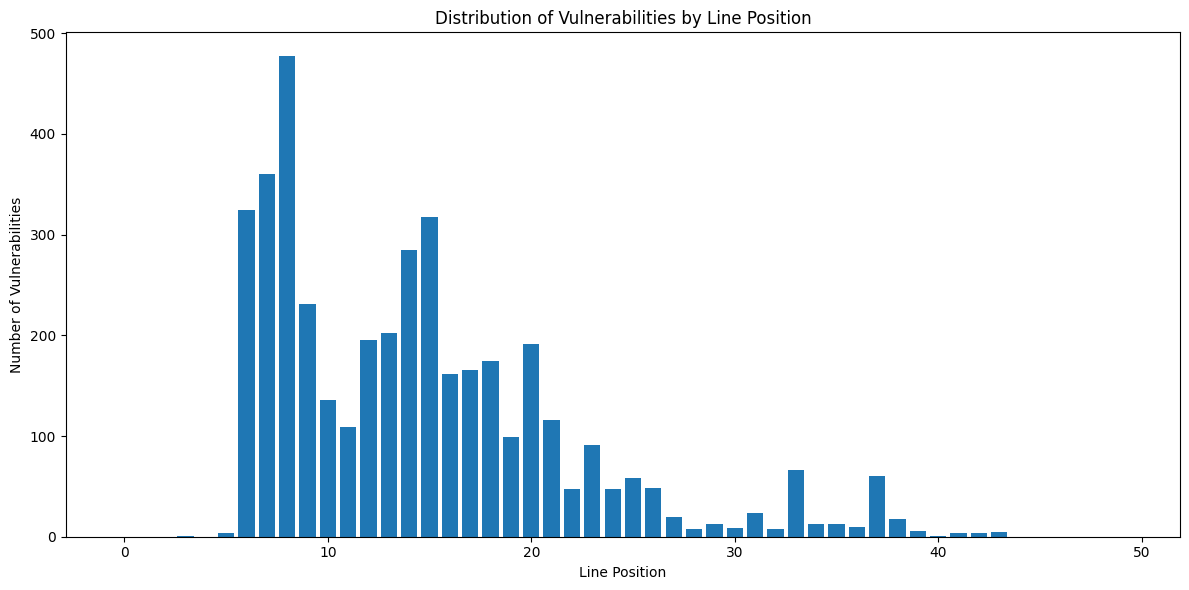

Saving tensors...
Dataset creation complete!
Dataset creation complete!


In [51]:
# Step 3: Tokenize and create tensors
print("Tokenizing data...")
train_sequences = tokenize_and_pad(train_data)
val_sequences = tokenize_and_pad(val_data)
test_sequences = tokenize_and_pad(test_data)

# Convert labels to tensors
train_labels_tensor = torch.stack(train_labels)
val_labels_tensor = torch.stack(val_labels)
test_labels_tensor = torch.stack(test_labels)

# Step 4: Create datasets
batch_size = 40
train_dataset = TensorDataset(train_sequences, train_labels_tensor)
val_dataset = TensorDataset(val_sequences, val_labels_tensor)
test_dataset = TensorDataset(test_sequences, test_labels_tensor)

# Step 5: Visualize label distribution
label_counts = torch.sum(train_labels_tensor, dim=0).numpy()
plt.figure(figsize=(12, 6))
plt.bar(range(MAX_FUNCTION_LINES), label_counts)
plt.xlabel('Line Position')
plt.ylabel('Number of Vulnerabilities')
plt.title('Distribution of Vulnerabilities by Line Position')
plt.tight_layout()
plt.show()

# Step 6: Save tensors
print("Saving tensors...")
torch.save(train_sequences, 'cwe_train_sequences.pt')
torch.save(train_labels_tensor, 'cwe_train_labels.pt')
torch.save(val_sequences, 'cwe_val_sequences.pt')
torch.save(val_labels_tensor, 'cwe_val_labels.pt')
torch.save(test_sequences, 'cwe_test_sequences.pt')
torch.save(test_labels_tensor, 'cwe_test_labels.pt')

print("Dataset creation complete!")